Linear Regression:
MSE: 3.6746002693146167
RMSE: 5.1855150134042765
R squared: 0.6730291968674778
Adjusted R squared: 0.6643897244269843
Decision Tree:
MSE: 3.6392156862745098
RMSE: 6.477896051566585
R squared: 0.4897381120415052
Adjusted R squared: 0.47625558248162636


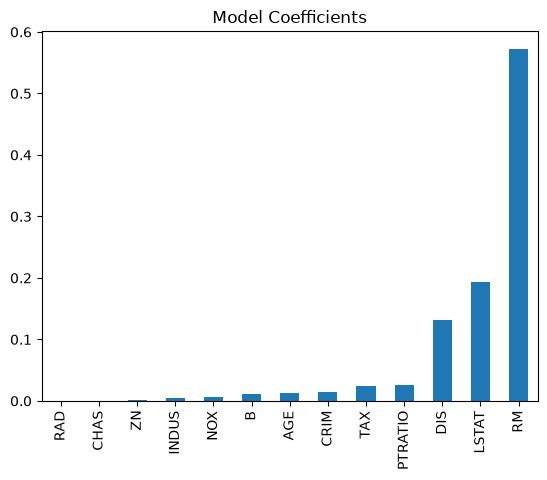

Random Forest:
MSE: 2.5384993464052408
RMSE: 3.9057066295458545
R squared: 0.8145083263204074
Adjusted R squared: 0.8096071235605807


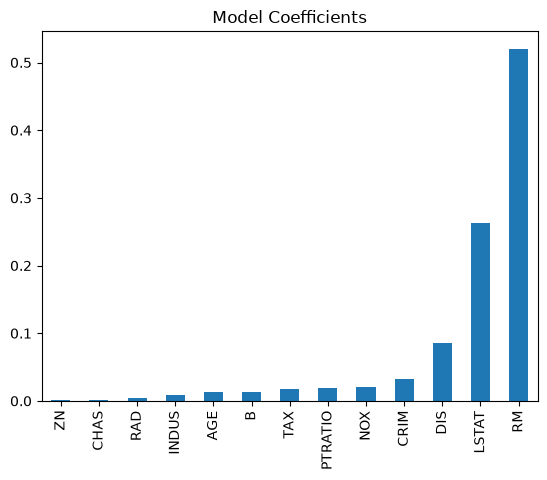

In [1]:
import pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

df = pd.read_csv("HousingData.csv")
df_X = df.drop(columns = "MEDV")
df_y = df["MEDV"]

train_X, temp_X, train_y, temp_y = train_test_split(df_X, df_y, test_size = 0.2, random_state=13)
val_X, test_X, val_y, test_y = train_test_split(temp_X, temp_y, test_size=0.5, random_state=13)

train_X = train_X.fillna(train_X.median())
val_X = val_X.fillna(val_X.median())
test_X = test_X.fillna(test_X.median)

modellinear = LinearRegression()
modellinear.fit(train_X, train_y)
prediction = modellinear.predict(val_X)
print("Linear Regression:")
print("MSE: " + str(mean_absolute_error(val_y, prediction)))
print("RMSE: " + str(root_mean_squared_error(val_y, prediction)))
r2 = r2_score(val_y, prediction)
print("R squared: " + str(r2))
n = df_X.shape[0]
p = df_X.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R squared: " + str(adj_r2))
modeltree = DecisionTreeRegressor(random_state=13)
modeltree.fit(train_X, train_y)
prediction = modeltree.predict(val_X)
print("Decision Tree:")
print("MSE: " + str(mean_absolute_error(val_y, prediction)))
print("RMSE: " + str(root_mean_squared_error(val_y, prediction)))
r2 = r2_score(val_y, prediction)
print("R squared: " + str(r2))
n = df_X.shape[0]
p = df_X.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R squared: " + str(adj_r2))
coef1 = pd.Series(modeltree.feature_importances_, df_X.columns).sort_values()
coef1.plot(kind='bar', title='Model Coefficients')
plt.show()
modelforest = RandomForestRegressor(n_estimators=750, random_state=13)
modelforest.fit(train_X, train_y)
prediction = modelforest.predict(val_X)
print("Random Forest:")
print("MSE: " + str(mean_absolute_error(val_y, prediction)))
print("RMSE: " + str(root_mean_squared_error(val_y, prediction)))
r2 = r2_score(val_y, prediction)
print("R squared: " + str(r2))
n = df_X.shape[0]
p = df_X.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R squared: " + str(adj_r2))
coef1 = pd.Series(modelforest.feature_importances_, df_X.columns).sort_values()
coef1.plot(kind='bar', title='Model Coefficients')
plt.show()